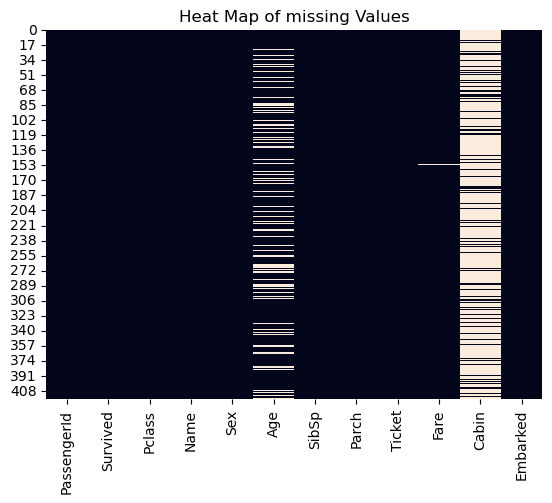

   Survived  Pclass     Sex      Age  SibSp  Parch     Fare Embarked Title  \
0         0       3    male   7.8292      0      0   7.8292        Q    Mr   
1         1       3  female   7.0000      1      0   7.0000        S   Mrs   
2         0       2    male   9.6875      0      0   9.6875        Q    Mr   
3         0       3    male   8.6625      0      0   8.6625        S    Mr   
4         1       3  female  12.2875      1      1  12.2875        S   Mrs   

      Deck  
0  Missing  
1  Missing  
2  Missing  
3  Missing  
4  Missing  
         Survived      Pclass         Age       SibSp       Parch        Fare
count  418.000000  418.000000  418.000000  418.000000  418.000000  418.000000
mean     0.363636    2.265550   35.606549    0.447368    0.392344   35.576535
std      0.481622    0.841838   55.842095    0.896760    0.981429   55.850103
min      0.000000    1.000000    0.000000    0.000000    0.000000    0.000000
25%      0.000000    1.000000    7.895800    0.000000    0.0000

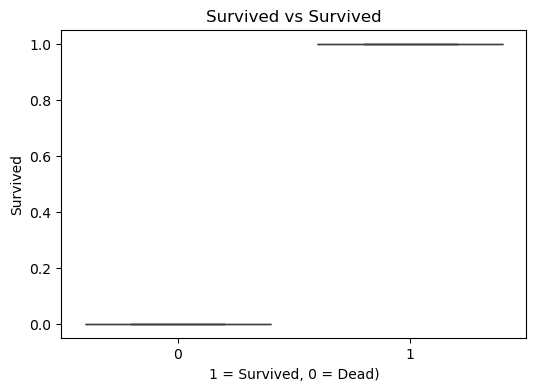

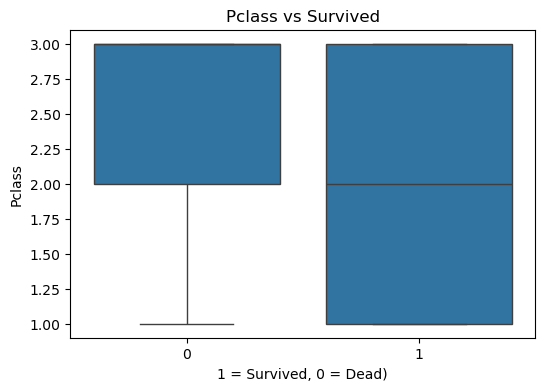

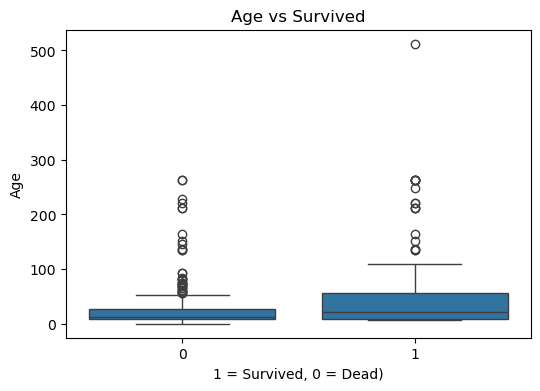

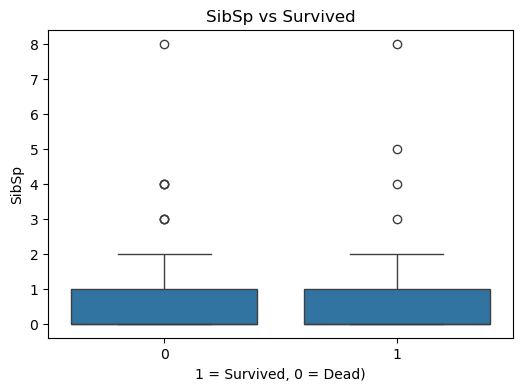

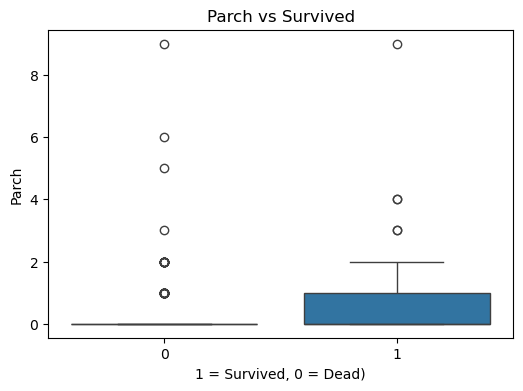

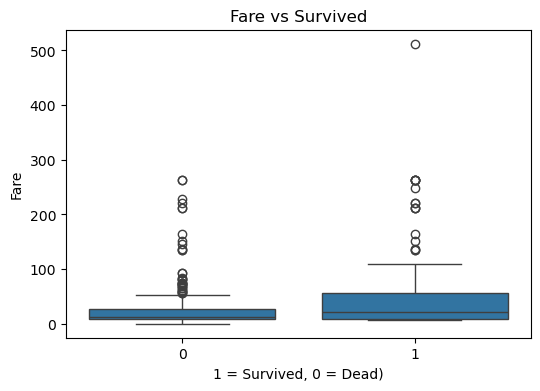

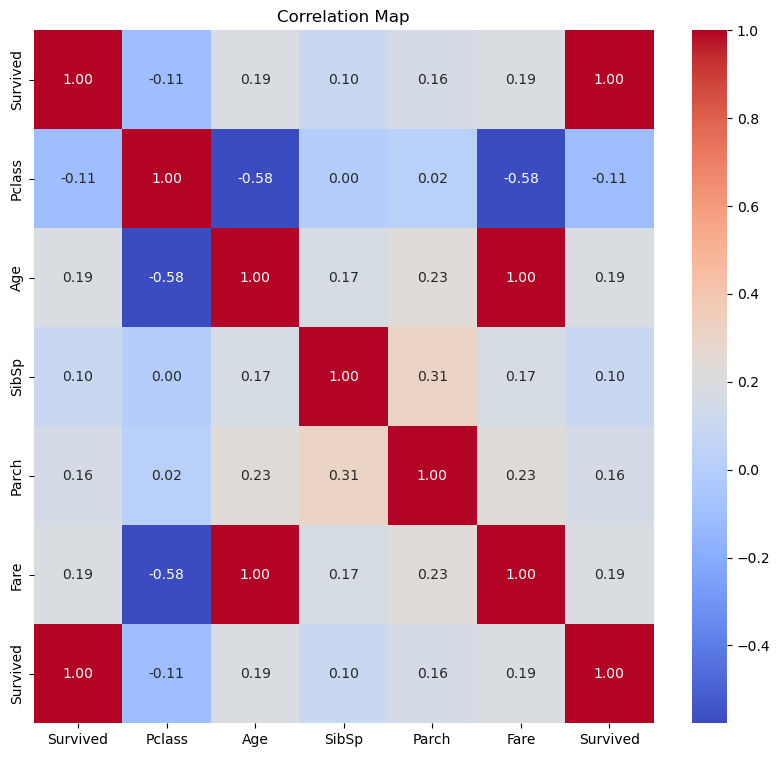

In [26]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


Data = pd.read_csv("../data/tested.csv")
# print(Data.head())
# print(Data.describe())
# print(Data.info())
# print(Data.isna().sum())

#visualizing the missing values from the dataset
sns.heatmap(Data.isna(), cbar=False)
plt.title("Heat Map of missing Values")
plt.show()


#dropping the PassengerId and Cabin columns
Data = Data.drop(columns=["PassengerId", "Ticket"])
# feature engineering
Data["Title"] = Data["Name"].str.extract(r",\s*([^\.]+)\.")
Data["Deck"] = Data["Cabin"].str[0]
Data["Deck"]= Data["Deck"].fillna("Missing")
Data = Data.drop(columns=["Name", "Cabin"])
Data["Age"]= Data["Fare"].fillna(Data["Age"].median())
Data["Fare"] = Data["Fare"].fillna(Data["Fare"].median())

print(Data.head())
print(Data.describe())
print(Data.info())
print(Data.isna().sum()) 
# seperating the features according to the data types
num_cols = Data.select_dtypes(include=["int64","float64"]).columns
cat_cols = Data.select_dtypes(include=["object"]).columns

X = Data.drop(columns=["Survived"])
y = Data["Survived"]


for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(data=Data, x="Survived", y=col)
    plt.title(f"{col} vs Survived")
    plt.xlabel("1 = Survived, 0 = Dead)")
    plt.show()


plt.figure(figsize=(10,9))
corr = Data[num_cols.tolist() + ["Survived"]].corr()
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Map")
plt.show()